# 2.4 Filter oversized regions (EXCLUDED)

Reads the 2D Sauvola segmentation from `2_1_segmentation.ipynb`, removes segmented regions whose
2D cross-section area exceeds a threshold (large blobs / merged artifacts) via
`remove_regions_above_area`, and saves the filtered segmentation for downstream use.

In [1]:
from pathlib import Path
import sys

import numpy as np
import matplotlib.pyplot as plt
from skimage import io, img_as_ubyte

BASE_DIR = Path.cwd().parent
PIXEL_SIZE_UM = 0.325                 # lateral pixel size (matches src/localization.py)
PIXEL_AREA_UM2 = PIXEL_SIZE_UM ** 2
MAX_AREA_UM2 = 2.5                    # remove regions larger than this

sys.path.append(str(BASE_DIR / 'src'))
from quantification import remove_regions_above_area, count_connexin_plaques

## 1. Load segmentation

In [2]:
seg_path = BASE_DIR / 'data' / 'segmented' / 'binary_sauvola2d_w21_k0_15.tiff'
seg = io.imread(seg_path) > 0  # ubyte 0/255 -> bool
n_planes = seg.shape[0]
print(f"Loaded segmentation: shape={seg.shape}, dtype=bool (from {seg_path.name})")

Loaded segmentation: shape=(441, 2033, 976), dtype=bool (from binary_sauvola2d_w21_k0_15.tiff)


## 2. Remove regions above the area threshold

In [3]:
seg_filtered = remove_regions_above_area(seg, max_area_um2=MAX_AREA_UM2, pixel_size_um=PIXEL_SIZE_UM)

counts_before = np.array([count_connexin_plaques(seg[z])[0] for z in range(n_planes)])
counts_after = np.array([count_connexin_plaques(seg_filtered[z])[0] for z in range(n_planes)])
print(f"Removing regions > {MAX_AREA_UM2} µm² (> {MAX_AREA_UM2 / PIXEL_AREA_UM2:.1f} px):")
print(f"  foreground pixels : {int(seg.sum())} -> {int(seg_filtered.sum())}")
print(f"  2D components      : {int(counts_before.sum())} -> {int(counts_after.sum())}")

Removing regions > 2.5 µm² (> 23.7 px):
  foreground pixels : 1823135 -> 247979
  2D components      : 69502 -> 55022


## 3. Save filtered segmentation

In [4]:
out_path = BASE_DIR / 'data' / 'segmented' / 'binary_sauvola2d_w21_k0_15_filtered_max2_5um2.tiff'
out_path.parent.mkdir(parents=True, exist_ok=True)
io.imsave(out_path, img_as_ubyte(seg_filtered))
print(f"Saved filtered segmentation -> {out_path}")

/home/rck292/cardiac_env/lib/python3.11/site-packages/skimage/_shared/utils.py:386: UserWarning: /home/rck292/Project/data/segmented/binary_sauvola2d_w21_k0_15_filtered_max2_5um2.tiff is a low contrast image
  return func(*args, **kwargs)


Saved filtered segmentation -> /home/rck292/Project/data/segmented/binary_sauvola2d_w21_k0_15_filtered_max2_5um2.tiff


## 4. QC — before/after on a sample plane

Overlays the segmentation on the deconvolved image (cropped to match the 2_1 segmentation frame).

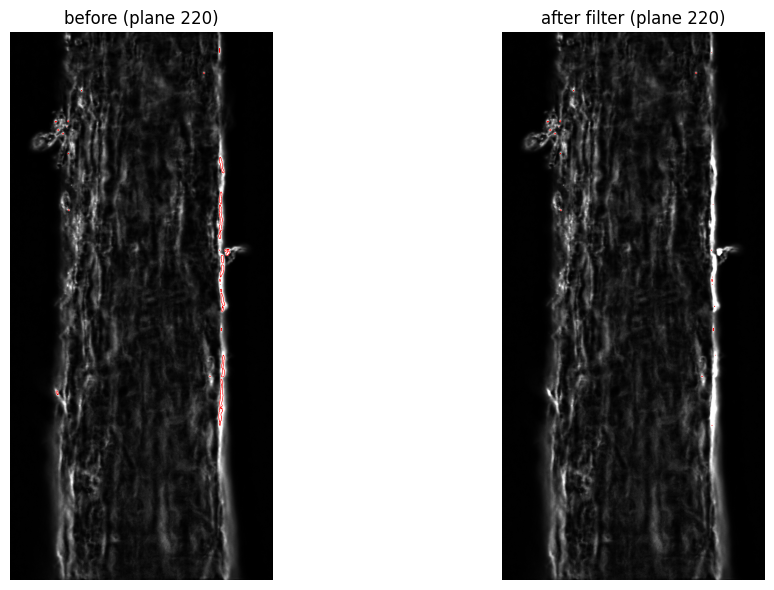

In [5]:
deconv_path = BASE_DIR / 'data' / 'preprocessed' / 'background_removed_and_deconvolved_img.tiff'
deconvolved = io.imread(deconv_path)[60:501, :, 23:999]  # match the 2_1 crop

p = n_planes // 2
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
for a, (title, b) in zip(ax, [('before', seg), ('after filter', seg_filtered)]):
    if deconvolved.shape == seg.shape:
        a.imshow(deconvolved[p], cmap='gray', vmax=np.percentile(deconvolved[p], 99.5))
    else:
        print(f"(deconvolved {deconvolved.shape} != seg {seg.shape}; showing mask only)")
        a.imshow(b[p], cmap='gray')
    a.contour(b[p], [0.5], colors='red', linewidths=0.4)
    a.set_title(f'{title} (plane {p})')
    a.axis('off')
plt.tight_layout()
plt.show()